Import everything needed

In [1]:
import sys
print(sys.executable)

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import json
import shutil
import tempfile
import time
import glob

import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib

from monai.losses import DiceLoss, DiceFocalLoss, DiceCELoss
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.transforms import (
    AsDiscrete,
    Activations,
)

from monai.config import print_config
from monai.metrics import DiceMetric
from monai.utils.enums import MetricReduction
from monai.networks.nets import SwinUNETR
from monai import data
from monai.data import decollate_batch
from functools import partial

import torch


print_config()

/home/akaube/PycharmProjects/medseg/venv/bin/python


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
2025-04-25 14:54:23.838355: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-25 14:54:23.862804: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-25 14:54:24.235996: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find Tensor

MONAI version: 1.3.0
Numpy version: 1.26.4
Pytorch version: 2.4.1+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 865972f7a791bf7b42efbcd87c8402bd865b329e
MONAI __file__: /usr/local/lib/python3.10/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.2
scikit-image version: 0.21.0
scipy version: 1.8.0
Pillow version: 9.0.1
Tensorboard version: 2.16.2
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.19.1+cu121
tqdm version: 4.66.4
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 1.3.5
einops version: 0.8.1
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional depen

In [2]:
print("CUDA version:", torch.version.cuda)
print("Is CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")

CUDA version: 12.1
Is CUDA available: True
Device name: NVIDIA GeForce RTX 4090


image shape: (512, 512, 75), mask shape: (512, 512, 75)


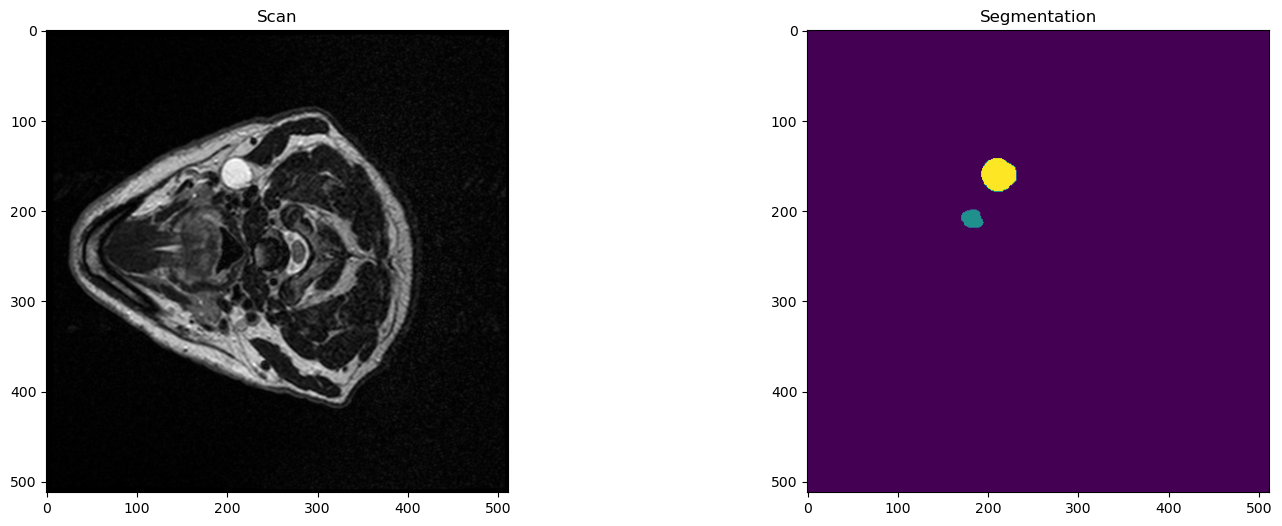

In [3]:
img_path = "/datasets/tdt4265/mic/open/HNTS-MRG/train/10/preRT/10_preRT_T2.nii.gz"
mask_path = "/datasets/tdt4265/mic/open/HNTS-MRG/train/10/preRT/10_preRT_mask.nii.gz"

img = nib.load(img_path).get_fdata()
mask = nib.load(mask_path).get_fdata()

print(f"image shape: {img.shape}, mask shape: {mask.shape}")

plt.figure("image", (18, 6))
plt.subplot(1, 2, 1)

plt.title("Scan")
plt.imshow(img[:, :, 40], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Segmentation")
plt.imshow(mask[:, :, 40])
plt.show()

Setup data directory

In [4]:
root_dir = tempfile.mkdtemp()
print(root_dir)

/tmp/tmp3a_5wum6


Setup average meter, fold reader, checkpoint saver

In [5]:
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = np.where(self.count > 0, self.sum / self.count, self.sum)

In [6]:
# Adjusts file paths using basedir
# Splits dataset into training and validation sets based on fold
def datafold_read(basedir, fold=0):
    tr = []
    val = []

    # Get images and masks
    images = sorted(glob.glob(basedir + "/train/*/preRT/*_preRT_T2.nii.gz"))
    masks = sorted(glob.glob(basedir + "/train/*/preRT/*_preRT_mask.nii.gz"))

    data_dicts = [{"image": img, "mask": msk} for img, msk
                  in zip(images, masks)]

    # Split data into training and validation sets
    # Should it be dict???
    tr = dict(data_dicts[int(len(data_dicts)/2):])
    val = dict(data_dicts[:int(len(data_dicts)/2)])

    tr = data_dicts[int(len(data_dicts)/2):]
    val = data_dicts[:int(len(data_dicts)/2)]

    return tr, val

In [7]:
def save_checkpoint(model, epoch, filename="model.pt",
                    best_acc=0, dir_add=root_dir):
    state_dict = model.state_dict()
    save_dict = {"epoch": epoch, "best_acc": best_acc,
                 "state_dict": state_dict}
    filename = os.path.join(dir_add, filename)
    torch.save(save_dict, filename)
    print("Saving checkpoint", filename)

Setup dataloaders

In [8]:
"""
            transforms.CropForegroundd(
                keys=["image", "mask"],
                source_key="image",
                k_divisible=[roi[0], roi[1], roi[2]],
            ),
            transforms.RandSpatialCropd(
                keys=["image", "mask"],
                roi_size=[roi[0], roi[1], roi[2]],
                random_size=False,
            ),
            """

"""
transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=0),
            transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=1),
            transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=2),
            transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
            transforms.RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
            transforms.RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),"""

def relabel_mask(mask):
    mask = mask.clone()
    mask[mask == 2] = 1  # if 2 should map to class 1
    return mask

def get_loader(batch_size, data_dir, fold, roi):
    data_dir = data_dir
    train_files, validation_files = datafold_read(basedir=data_dir, fold=fold)

    # Define transforms
    train_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "mask"]),
    transforms.EnsureChannelFirstd(keys=["image", "mask"]),
        
    # transforms.EnsureTyped(keys=["mask"], dtype=torch.long),  
    # transforms.Lambdad(keys=["mask"], func=relabel_mask),
        
    # Convert to one-hot for 3 classes (background + 2 tumor types)
    transforms.AsDiscreted(keys=["mask"], to_onehot=3),
    
    transforms.Orientationd(keys=["image", "mask"], axcodes="RAS"),


    # two labels or boths
    # nnUNet MIC DFZK say to use (winner of challenge did)
    # decide a_min a_max, or use normalizeintensity
    transforms.ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),


    transforms.CropForegroundd(keys=["image", "mask"], source_key="image"),
    transforms.ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(512, 512, 96)),

    # Add augmentations
    transforms.RandRotate90d(keys=["image", "mask"], prob=0.5, max_k=3),
    transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=[0, 1, 2]),
    transforms.RandShiftIntensityd(keys=["image"], prob=0.5, offsets=0.1),
    transforms.RandZoomd(keys=["image", "mask"], prob=0.5, min_zoom=0.9, max_zoom=1.1),
    transforms.RandGaussianNoised(keys=["image"], prob=0.3, mean=0.0, std=0.1),
    transforms.RandGaussianSmoothd(keys=["image"], prob=0.3, sigma_x=(0.5, 1.0)),
    transforms.RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.7, 1.3)),
        
    # Sample patches ensuring both tumor types are represented
    transforms.RandCropByPosNegLabeld(
        keys=["image", "mask"],
        label_key="mask",
        spatial_size=roi,
        pos=3,  # Sample more patches with tumors
        neg=1,  # And some background
        num_samples=4,
        # label_indices=[1, 2],  # Specifically sample from both tumor classes
    ),
    
    transforms.ToTensord(keys=["image", "mask"]),
])
    
    val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "mask"]),
    transforms.EnsureChannelFirstd(keys=["image", "mask"]),
    # transforms.EnsureTyped(keys=["mask"], dtype=torch.long),    # ensure label stays as [B,H,W,D]

    # Convert to one-hot for 3 classes (background + 2 tumor types)
    transforms.AsDiscreted(keys=["mask"], to_onehot=3),
        
    transforms.Orientationd(keys=["image", "mask"], axcodes="RAS"),
    transforms.ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    transforms.CropForegroundd(keys=["image", "mask"], source_key="image"),
    transforms.ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(512, 512, 96)),
        
    transforms.ToTensord(keys=["image", "mask"]),
])

    # Make datasets and dataloaders
    # CACHE DATASET?
    train_ds = data.Dataset(data=train_files, transform=train_transform)
    train_loader = data.DataLoader(train_ds,
        batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=False  # num_workers = 8?
    )
    val_ds = data.Dataset(data=validation_files, transform=val_transform)
    val_loader = data.DataLoader(val_ds,
        batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=False
    )

    return train_loader, val_loader

Setup data directory and hyperparameters

In [9]:
data_dir = "/datasets/tdt4265/mic/open/HNTS-MRG"

roi = (256,256,96) # (96,96,96) # (64,64,64)
batch_size = 2
sw_batch_size = 4
fold = 1 # 5
infer_overlap = 0.5
max_epochs = 100
val_every = 5

train_loader, val_loader = get_loader(batch_size, data_dir, fold, roi)

/usr/local/lib/python3.10/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


Create SwinUNETR model

In [10]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using " + "cuda" if torch.cuda.is_available() else "cpu")

model = SwinUNETR(
    img_size=roi,
    in_channels=1,
    out_channels=3,             # Detect background and two tumors (head and neck)
    feature_size=48,
    drop_rate=0.2,
    attn_drop_rate=0.1,
    dropout_path_rate=0.1,
    use_checkpoint=True,
).to(device)

Using cuda


Define optimizer and loss function

In [12]:
from monai.metrics import HausdorffDistanceMetric

torch.backends.cudnn.benchmark = True

torch.cuda.empty_cache()

from torch.cuda.amp import autocast, GradScaler

# Class weights for loss function - adjust based on class prevalence
# Give higher weights to tumor classes if they're less common
class_weights = torch.tensor([0.2, 1.0, 1.0]).to(device)  # Example weights

# Use multi-class loss function
loss_function = DiceCELoss(
    to_onehot_y=False,  # We already converted to one-hot in the transforms
    softmax=True,       # Use softmax for multi-class (not sigmoid)
    ce_weight=class_weights
)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-6)
dice_metric = DiceMetric(include_background=False, reduction=MetricReduction.MEAN_BATCH, get_not_nans=True)

"""
post_pred = transforms.Compose([
    transforms.Activationsd(keys="pred", softmax=True),  # softmax instead of sigmoid
    transforms.AsDiscreted(keys="pred", argmax=True),    # argmax instead of threshold
    transforms.ToOneHotd(keys="pred", num_classes=3)     # Convert back to one-hot for metric calculation
])
"""

# Metrics for multi-class evaluation
hausdorff_metric = HausdorffDistanceMetric(include_background=False, percentile=95.0)

scaler = GradScaler()
max_epochs = 30 # 100

epoch_losses = []

# Create directory for saving models
os.makedirs("./models", exist_ok=True)

for epoch in range(max_epochs):
    print(f"Epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    
    for batch_data in train_loader:
        inputs = batch_data["image"].to(device, non_blocking=True)
        labels = batch_data["mask"].to(device, non_blocking=True)
        
        # print(torch.unique(labels)) # should be 0,1

        # Clear out the gradients of all parameters that the optimizer is tracking
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss = loss_function(outputs, labels)

        # Backward pass with scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

        print(".", end="")
    # torch.cuda.empty_cache()
    
    # Update learning rate
    scheduler.step()
    
    avg_loss = epoch_loss / len(train_loader)
    print(f"Avg loss: {avg_loss:.4f}")
    
    """
    # Validation
    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            val_dice = 0
            val_hausdorff = 0
            for val_data in val_loader:
                val_inputs = val_data["image"].to(device)
                val_labels = val_data["mask"].to(device)
                
                # Use sliding window inference for better validation
                roi_size = roi
                val_outputs = sliding_window_inference(
                    val_inputs, roi_size, sw_batch_size, model, overlap=infer_overlap
                )
                
                # Post-process outputs
                val_outputs = {"pred": val_outputs}
                val_outputs = post_pred(val_outputs)["pred"]
                
                # Compute metrics
                dice_metric(y_pred=val_outputs, y=val_labels)
                hausdorff_metric(y_pred=val_outputs, y=val_labels)
            
            # Aggregate metrics
            metric_dice = dice_metric.aggregate().item()
            metric_hausdorff = hausdorff_metric.aggregate().item()
            dice_metric.reset()
            hausdorff_metric.reset()
            
            print(f"Validation Dice: {metric_dice:.4f}")
            print(f"Validation Hausdorff Distance (95%): {metric_hausdorff:.4f}")
            
            # Save best model
            if metric_dice > best_metric:
                best_metric = metric_dice
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), f"./models/best_model_fold{fold}.pth")
                print("Saved new best model")
    """
    
    # Add to epoch losses
    epoch_losses.append(avg_loss)

Epoch 1/30


/tmp/ipykernel_86464/2442032353.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_86464/2442032353.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.10/dist-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


.................................Avg loss: 0.7887
Epoch 2/30
.................................Avg loss: 0.7521
Epoch 3/30
.................................Avg loss: 0.7353
Epoch 4/30
.................................Avg loss: 0.7279
Epoch 5/30
.................................Avg loss: 0.7217
Epoch 6/30
.................................Avg loss: 0.7145
Epoch 7/30
.................................Avg loss: 0.7098
Epoch 8/30
.................................Avg loss: 0.7093
Epoch 9/30
.................................Avg loss: 0.7005
Epoch 10/30
.................................Avg loss: 0.7028
Epoch 11/30
.................................Avg loss: 0.6988
Epoch 12/30
.................................Avg loss: 0.7005
Epoch 13/30


KeyboardInterrupt: 

Plot loss

ValueError: x and y must have same first dimension, but have shapes (30,) and (5,)

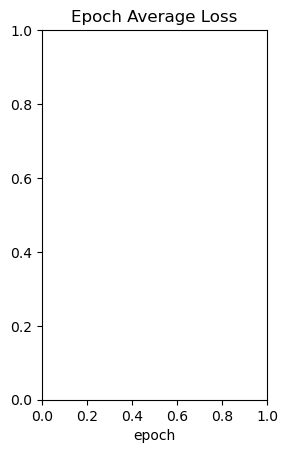

In [23]:
plt.figure("training")
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
plt.xlabel("epoch")
plt.plot(np.arange(1, max_epochs+1), epoch_losses, color="red")

Create dataloader for the test set

In [13]:
def test_data_read(basedir):

    # Get images and masks
    images = sorted(glob.glob(basedir + "/test/*/preRT/*_preRT_T2.nii.gz"))
    masks = sorted(glob.glob(basedir + "/test/*/preRT/*_preRT_mask.nii.gz"))

    data_dicts = [{"image": img, "mask": msk} for img, msk in zip(images, masks)]
    
    return data_dicts

def get_test_loader(batch_size, data_dir, fold, roi):
    data_dir = data_dir
    test_files = test_data_read(data_dir)

    # Define transforms
    test_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "mask"]),
    transforms.EnsureChannelFirstd(keys=["image", "mask"]),
        
    # transforms.EnsureTyped(keys=["mask"], dtype=torch.long),  
    transforms.Lambdad(keys=["mask"], func=relabel_mask),
        
    transforms.ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    
    transforms.CropForegroundd(keys=["image", "mask"], source_key="image"),
    transforms.ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(512, 512, 96)),
    
    transforms.ToTensord(keys=["image", "mask"]),
    ])

    # Make datasets and dataloaders
    test_ds = data.Dataset(data=test_files, transform=test_transform)
    test_loader = data.DataLoader(test_ds,
        batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=False  # num_workers = 8?
    )

    return test_loader

In [14]:
test_loader = get_test_loader(batch_size, data_dir, fold, roi)

model.eval()

from monai.inferers import SlidingWindowInferer

model_inferer_test = SlidingWindowInferer(roi_size=[128, 128, 128], sw_batch_size=4, overlap=0.6)

"""    
partial(
    sliding_window_inference,
    roi_size= [128,128,128], # [roi[0], roi[1], roi[2]],
    sw_batch_size=4, # 1
    predictor=model,
    overlap=0.6, # 0.6
))
"""

with torch.no_grad():
    for batch_data in test_loader:
        image = batch_data["image"].cuda()
        
        logits = model_inferer_test(image, network=model)  # shape: [B, C, D, H, W]
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        for b in range(preds.shape[0]):
            pred = preds[b].cpu().numpy()  # shape: [C, D, H, W]

            # Convert to single-channel mask
            seg_out = np.zeros(pred.shape[1:], dtype=np.uint8)
            if pred.shape[0] >= 1:
                seg_out[pred[0] == 1] = 1
            if pred.shape[0] >= 2:
                seg_out[pred[1] == 1] = 2
        
        """
        prob = torch.sigmoid(model_inferer_test(image))
        print(prob.shape)
        seg = prob[0].detach().cpu().numpy()
        seg = (seg > 0.5).astype(np.int8)
        seg_out = np.zeros((seg.shape[1], seg.shape[2], seg.shape[3]))
        seg_out[seg[0] == 1] = 1
        seg_out[seg[1] == 1] = 2
        """

/usr/local/lib/python3.10/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


Visualize output and compare with label

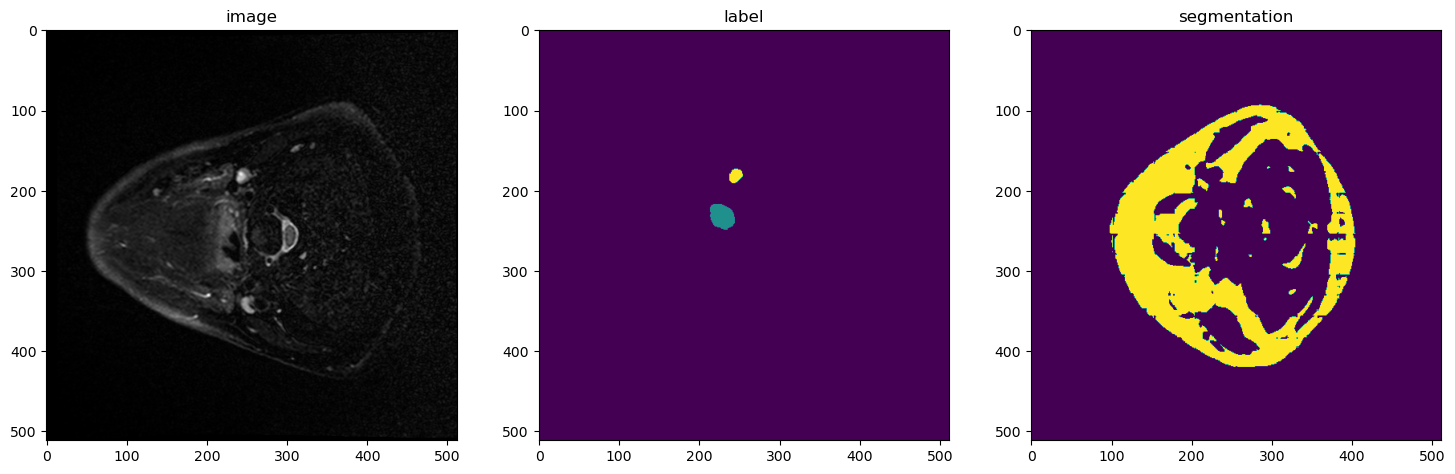

In [24]:
slice_num = 35
case_num = 88

img_add = data_dir + "/test/" + str(case_num) + "/preRT/" + str(case_num) + "_preRT_T2.nii.gz"
label_add = data_dir + "/test/" + str(case_num) + "/preRT/" + str(case_num) + "_preRT_mask.nii.gz"

img = nib.load(img_add).get_fdata()
label = nib.load(label_add).get_fdata()
plt.figure("image", (18, 6))
plt.subplot(1, 3, 1)
plt.title("image")
plt.imshow(img[:, :, slice_num], cmap="gray")
plt.subplot(1, 3, 2)
plt.title("label")
plt.imshow(label[:, :, slice_num])
plt.subplot(1, 3, 3)
plt.title("segmentation")
plt.imshow(seg_out[:, :, slice_num])
plt.show()

Export .nii.gz file for visualization

In [47]:
# Load the original image (to get affine and header)
img_nib = nib.load(data_dir + "/test/" + str(case_num) + "/preRT/" + str(case_num) + "_preRT_T2.nii.gz")

# Create new NIfTI image
seg_nib = nib.Nifti1Image(seg_out.astype(np.uint8), affine=img_nib.affine, header=img_nib.header)

# Save
nib.save(seg_nib, "~/medsegout/segmentation_output.nii.gz")